In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (
    train_test_split,
    KFold,
    RandomizedSearchCV,
    learning_curve,
    cross_validate,
)
from sklearn.linear_model import RidgeCV
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
from sklearn.pipeline import Pipeline

Declare constants.
Define scoring metrics: r2, mean absolute error and root mean squarred error.
Divide features to categorical and numeric.

In [4]:
DATA_PATH = "../datasets/Ames_Housing_Data.csv"
TARGET = "SalePrice"
RANDOM_STATE = 13
TEST_SIZE = 0.2

SCORING = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "rmse": "neg_root_mean_squared_error",
}

NUMERIC_FEATURES = [
    "MS SubClass",
    "Lot Frontage",
    "Lot Area",
    "Overall Qual",
    "Overall Cond",
    "Years since Built",
    "Years since Remod/Add",
    "Mas Vnr Area",
    "BsmtFin SF 1",
    "BsmtFin SF 2",
    "Bsmt Unf SF",
    "Total Bsmt SF",
    "1st Flr SF",
    "2nd Flr SF",
    "Low Qual Fin SF",
    "Gr Liv Area",
    "Bsmt Full Bath",
    "Bsmt Half Bath",
    "Full Bath",
    "Half Bath",
    "Bedroom AbvGr",
    "Kitchen AbvGr",
    "TotRms AbvGrd",
    "Fireplaces",
    "Years since Garage Blt",
    "Garage Cars",
    "Garage Area",
    "Wood Deck SF",
    "Open Porch SF",
    "Enclosed Porch",
    "3Ssn Porch",
    "Screen Porch",
    "Pool Area",
    "Misc Val",
    "Mo Sold",
]

CATEGORICAL_FEATURES = [
    "MS Zoning",
    "Street",
    "Alley",
    "Lot Shape",
    "Land Contour",
    "Utilities",
    "Lot Config",
    "Land Slope",
    "Neighborhood",
    "Condition 1",
    "Condition 2",
    "Bldg Type",
    "House Style",
    "Roof Style",
    "Roof Matl",
    "Exterior 1st",
    "Exterior 2nd",
    "Mas Vnr Type",
    "Exter Qual",
    "Exter Cond",
    "Foundation",
    "Bsmt Qual",
    "Bsmt Cond",
    "Bsmt Exposure",
    "BsmtFin Type 1",
    "BsmtFin Type 2",
    "Heating",
    "Heating QC",
    "Central Air",
    "Electrical",
    "Kitchen Qual",
    "Functional",
    "Fireplace Qu",
    "Garage Type",
    "Garage Finish",
    "Garage Qual",
    "Garage Cond",
    "Paved Drive",
    "Pool QC",
    "Fence",
    "Misc Feature",
    "Sale Type",
    "Sale Condition",
]

Read data.
Get its shape, columns types and other info.
Check if there are any n/a values.

In [5]:
data = pd.read_csv(DATA_PATH)

pd.set_option("display.max_columns", None)
print(data.shape)
display(data.head())
data.info()
missing_counts = data.isna().sum()
missing_counts[missing_counts > 0]

(2930, 81)


,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,Lot Config,Land Slope,Neighborhood,Condition 1,Condition 2,Bldg Type,House Style,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Roof Style,Roof Matl,Exterior 1st,Exterior 2nd,Mas Vnr Type,Mas Vnr Area,Exter Qual,Exter Cond,Foundation,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin SF 1,BsmtFin Type 2,BsmtFin SF 2,Bsmt Unf SF,Total Bsmt SF,Heating,Heating QC,Central Air,Electrical,1st Flr SF,2nd Flr SF,Low Qual Fin SF,Gr Liv Area,Bsmt Full Bath,Bsmt Half Bath,Full Bath,Half Bath,Bedroom AbvGr,Kitchen AbvGr,Kitchen Qual,TotRms AbvGrd,Functional,Fireplaces,Fireplace Qu,Garage Type,Garage Yr Blt,Garage Finish,Garage Cars,Garage Area,Garage Qual,Garage Cond,Paved Drive,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,5,1960,1960,Hip,CompShg,BrkFace,Plywood,Stone,112.0,TA,TA,CBlock,TA,Gd,Gd,BLQ,639.0,Unf,0.0,441.0,1080.0,GasA,Fa,Y,SBrkr,1656,0,0,1656,1.0,0.0,1,0,3,1,TA,7,Typ,2,Gd,Attchd,1960.0,Fin,2.0,528.0,TA,TA,P,210,62,0,0,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,CBlock,TA,TA,No,Rec,468.0,LwQ,144.0,270.0,882.0,GasA,TA,Y,SBrkr,896,0,0,896,0.0,0.0,1,0,2,1,TA,5,Typ,0,NaN,Attchd,1961.0,Unf,1.0,730.0,TA,TA,Y,140,0,0,0,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,6,6,1958,1958,Hip,CompShg,Wd Sdng,Wd Sdng,BrkFace,108.0,TA,TA,CBlock,TA,TA,No,ALQ,923.0,Unf,0.0,406.0,1329.0,GasA,TA,Y,SBrkr,1329,0,0,1329,0.0,0.0,1,1,3,1,Gd,6,Typ,0,NaN,Attchd,1958.0,Unf,1.0,312.0,TA,TA,Y,393,36,0,0,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,Corner,Gtl,NAmes,Norm,Norm,1Fam,1Story,7,5,1968,1968,Hip,CompShg,BrkFace,BrkFace,NaN,0.0,Gd,TA,CBlock,TA,TA,No,ALQ,1065.0,Unf,0.0,1045.0,2110.0,GasA,Ex,Y,SBrkr,2110,0,0,2110,1.0,0.0,2,1,3,1,Ex,8,Typ,2,TA,Attchd,1968.0,Fin,2.0,522.0,TA,TA,Y,0,0,0,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,5,5,1997,1998,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,GLQ,791.0,Unf,0.0,137.0,928.0,GasA,Gd,Y,SBrkr,928,701,0,1629,0.0,0.0,2,1,3,1,TA,6,Typ,1,TA,Attchd,1997.0,Fin,2.0,482.0,TA,TA,Y,212,34,0,0,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2930 non-null   int64  
 1   MS SubClass      2930 non-null   int64  
 2   MS Zoning        2930 non-null   str    
 3   Lot Frontage     2440 non-null   float64
 4   Lot Area         2930 non-null   int64  
 5   Street           2930 non-null   str    
 6   Alley            198 non-null    str    
 7   Lot Shape        2930 non-null   str    
 8   Land Contour     2930 non-null   str    
 9   Utilities        2930 non-null   str    
 10  Lot Config       2930 non-null   str    
 11  Land Slope       2930 non-null   str    
 12  Neighborhood     2930 non-null   str    
 13  Condition 1      2930 non-null   str    
 14  Condition 2      2930 non-null   str    
 15  Bldg Type        2930 non-null   str    
 16  House Style      2930 non-null   str    
 17  Overall Qual     2930 non

Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64

Add new columns calculated from existing years column to improve readability.
Declare X, drop PID as not relevant, drop target and years column we transformed in previous step.
Declare y.
Convert categorical columns to pandas category dtype (to use hist boosting native category support).
Split data to 80% train and 20% test.

In [6]:
data["Years since Built"] = data["Yr Sold"] - data["Year Built"]
data["Years since Remod/Add"] = data["Yr Sold"] - data["Year Remod/Add"]
data["Years since Garage Blt"] = data["Yr Sold"] - data["Garage Yr Blt"]

X = data.drop(
    columns=[TARGET, "Year Built", "Year Remod/Add", "Garage Yr Blt", "Yr Sold", "PID"]
)
y = data[TARGET]

for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype("category")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Lets first try to work with parallel trees - RandomForestRegressor.
It does not need scaling, so for numeric features we use only SimpleImputer, to fill missing values.
For categorical features we also use SimpleImputer, then OneHotEncoder to get separate column for each category value.
Declare preprocessor, then model pipeline.

In [7]:
numeric_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    verbose_feature_names_out=False,
)

random_forest_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", RandomForestRegressor(random_state=RANDOM_STATE)),
    ]
)

For random forest there are lots of tuning parameters, so we use RandomizedSearchCV to save time and pick only 20 combinations.

In [8]:
param_dist = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__max_features": ["sqrt", 0.3, 0.5, 0.7],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
}

search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    random_state=13,
    refit="r2",
    return_train_score=True,
)

Train models.

In [ ]:
search.fit(X_train, y_train)

best_random_forest_model = search.best_estimator_

print("Best params:", search.best_params_)
print("Best validation mean r2 score:", search.best_score_)

random_forest_results = (
    pd.DataFrame(search.cv_results_).sort_values("mean_test_r2", ascending=False).head()
)

random_forest_results[["mean_test_r2", "mean_test_mae", "mean_test_rmse"]]

Best params: {'regressor__n_estimators': 500, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.5, 'regressor__max_depth': 30}
Best validation mean r2 score: 0.8993666242851799


,mean_test_r2,mean_test_mae,mean_test_rmse
1,0.899367,-15361.388278,-24870.807372
7,0.899070,-15469.989949,-24905.003273
13,0.898269,-15360.175941,-25015.382289
8,0.896180,-15522.473071,-25284.260115
9,0.896175,-15570.263312,-25298.635842


Execution time is 3:32 min. Metrics are not bad for first try, but we need to compare it with other models to evaluate.

Now let's try consistent trees flow - HistGradientBoostingRegressor.
Gradient boosting does not need scaling, handles missing feature values and categories encoding, so just straighforward model definition.

In [16]:
hist_boost_model = HistGradientBoostingRegressor(
    categorical_features="from_dtype",
    random_state=RANDOM_STATE,
)

Randomized search again with most common parameters for hist boosting.

In [17]:
param_dist = {
    "learning_rate": [0.03, 0.05, 0.1],
    "max_iter": [200, 300, 500],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [5, 10, 20],
    "l2_regularization": [0.0, 0.01, 0.1, 1.0],
}

search = RandomizedSearchCV(
    estimator=hist_boost_model,
    param_distributions=param_dist,
    n_iter=30,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    refit="r2",
    return_train_score=True,
    error_score="raise",
)

Train models.

In [18]:
search.fit(X_train, y_train)

best_hist_boost_model = search.best_estimator_

print("Best params:", search.best_params_)
print("Best validation mean r2 score:", search.best_score_)

hist_boost_results = (
    pd.DataFrame(search.cv_results_).sort_values("mean_test_r2", ascending=False).head()
)

hist_boost_results[["mean_test_r2", "mean_test_mae", "mean_test_rmse"]]

Best params: {'min_samples_leaf': 5, 'max_leaf_nodes': 15, 'max_iter': 200, 'learning_rate': 0.1, 'l2_regularization': 0.01}
Best validation mean r2 score: 0.9174685791416539


,mean_test_r2,mean_test_mae,mean_test_rmse
10,0.917469,-13857.034881,-22608.729146
1,0.917328,-13641.309968,-22573.881035
2,0.916770,-13709.885642,-22660.145742
9,0.916659,-13700.076375,-22675.210461
29,0.916462,-13823.308435,-22731.718605


Execution time reduced significantly, to 1:51 min.
Validation metrics got better.
The best results so far.

Finally let's try simple linear regression with l2 regularization.
Don't forget to add scaler for numeric values and imputer for both numeric and categorical.

In [20]:
numeric_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
)

categorical_pipeline = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("num", numeric_pipeline, NUMERIC_FEATURES),
        ("cat", categorical_pipeline, CATEGORICAL_FEATURES),
    ],
    verbose_feature_names_out=False,
)

ridge_model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("regressor", RidgeCV(alphas=np.logspace(-3, 3, 20))),
    ]
)

Perform cross validation.

In [21]:
cv_results = cross_validate(
    estimator=ridge_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=SCORING,
    n_jobs=-1,
    return_train_score=True,
)

ridge_results = pd.DataFrame(cv_results)

print("Validation mean r2 score:", ridge_results.test_r2.mean())
print("Validation mean MAE score:", ridge_results.test_mae.mean())
print("Validation mean RMSE score:", ridge_results.test_rmse.mean())

Validation mean r2 score: 0.84621661827241
Validation mean MAE score: -16483.210901431572
Validation mean RMSE score: -29942.06597234065


metrics are quite a bit worse than such in validation datasets from previous models.

Let's summarize all metrics across models

In [22]:
summary = pd.DataFrame(
    [
        {
            "model": "RandomForest",
            "cv_r2": random_forest_results["mean_test_r2"].iloc[0],
            "cv_mae": random_forest_results["mean_test_mae"].iloc[0],
            "cv_rmse": random_forest_results["mean_test_rmse"].iloc[0],
        },
        {
            "model": "HistGradientBoosting",
            "cv_r2": hist_boost_results["mean_test_r2"].iloc[0],
            "cv_mae": hist_boost_results["mean_test_mae"].iloc[0],
            "cv_rmse": hist_boost_results["mean_test_rmse"].iloc[0],
        },
        {
            "model": "RidgeCV",
            "cv_r2": ridge_results.test_r2.mean(),
            "cv_mae": ridge_results.test_mae.mean(),
            "cv_rmse": ridge_results.test_rmse.mean(),
        },
    ]
)

summary.sort_values("cv_r2", ascending=False)

,model,cv_r2,cv_mae,cv_rmse
1,HistGradientBoosting,0.917469,-13857.034881,-22608.729146
0,RandomForest,0.899367,-15361.388278,-24870.807372
2,RidgeCV,0.846217,-16483.210901,-29942.065972


Hist Gradient boosting has the best metrics, let's investigate it.

In [23]:
y_pred = best_hist_boost_model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
residuals = y_test - y_pred

print("Test r2 score:", r2)
print("Test MAE score:", mae)
print("Test RMSE score:", rmse)

Test r2 score: 0.9041900244477303
Test MAE score: 14347.454832563342
Test RMSE score: 25358.38248129413


Test metrics are slightly worse, but not critical. It is still better than other models validation metrics.

Let's build a graph comparison of predicted and actual sales prices.
From this graph we can see that prediction errors become more dispersed for more expensive houses.

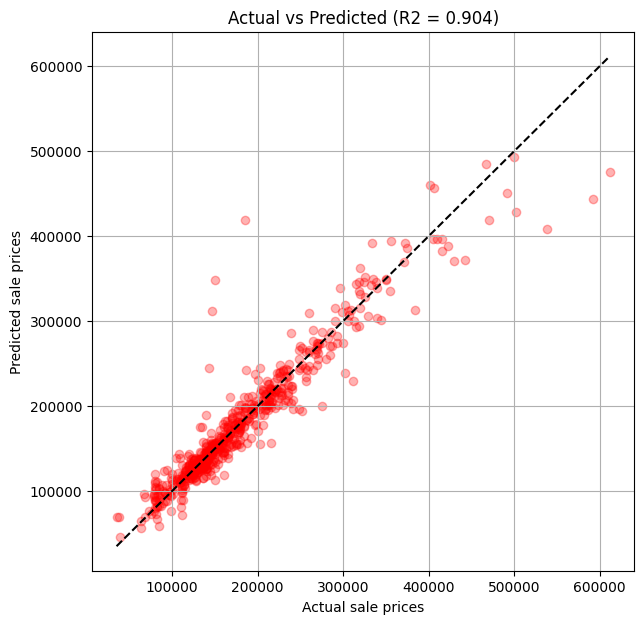

In [24]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, color="red")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black",
)
plt.grid(True)
plt.title(f"Actual vs Predicted (R2 = {r2:.3f})")
plt.xlabel("Actual sale prices")
plt.ylabel("Predicted sale prices")
plt.show()

Let's build Residual Plot graph, which shows how big error model makes depending on sales price.
From this graph we can see - variance residuals increase for higher predicted prices, heteroscedasticity in smarter words.

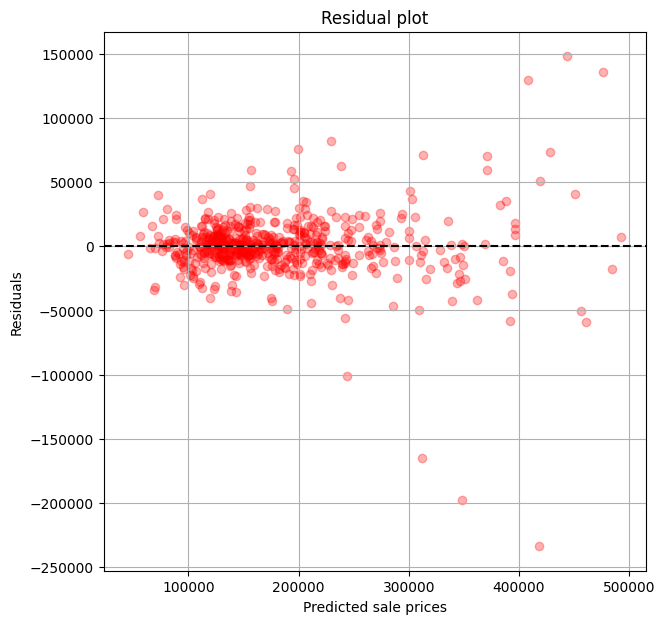

In [25]:
plt.figure(figsize=(7, 7))
plt.scatter(y_pred, residuals, alpha=0.3, color="red")
plt.axhline(y=0, linestyle="--", color="black")
plt.grid(True)
plt.title("Residual plot")
plt.xlabel("Predicted sale prices")
plt.ylabel("Residuals")
plt.show()

Histogram of residuals shows the info from previous graph but in format: error/number of appearances.

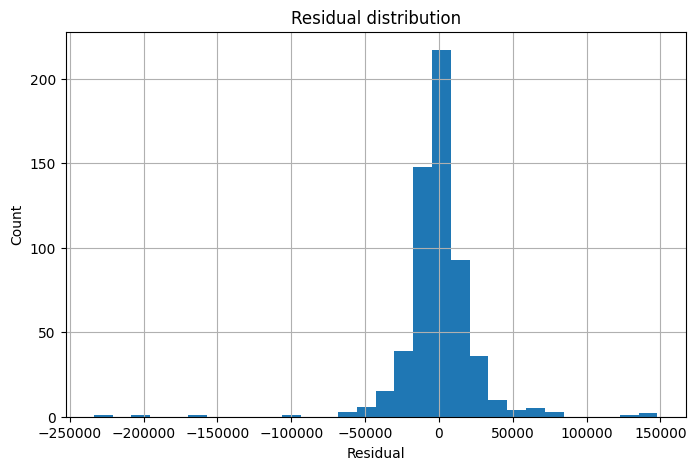

In [33]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.title("Residual distribution")
plt.xlabel("Residual")
plt.ylabel("Count")
plt.grid(True)
plt.show()

Permutation importances histogram shows quality decrease after shuffling feature values.
From this histogram the most important features are:  Overall Quality and Ground Livivng Area, that are pretty obvious features.
Low importance does not always mean that feature is useless, especially if features are correlated.

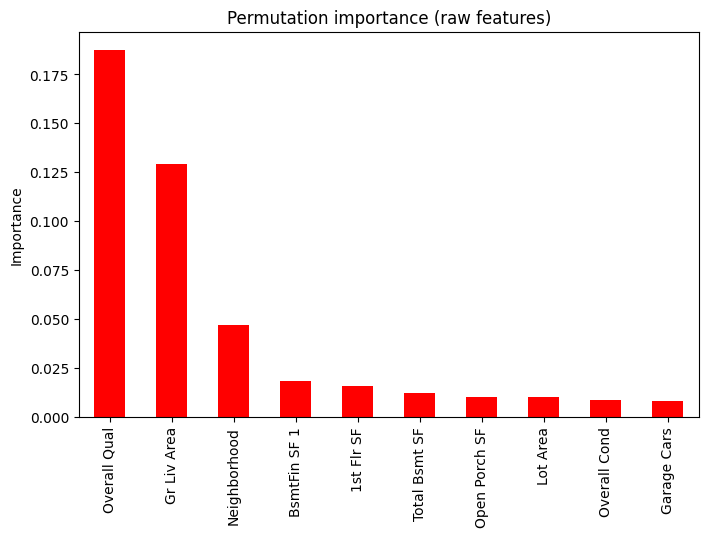

In [26]:
perm = permutation_importance(
    best_hist_boost_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    scoring="r2",
    n_jobs=-1,
)

raw_importances = pd.Series(
    perm.importances_mean,
    index=X_test.columns,
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
raw_importances.head(10).plot.bar(color="red")
plt.title("Permutation importance (raw features)")
plt.ylabel("Importance")
plt.show()

Error by price segment shows mean absolute error difference between price groups.
Higher prices tend to have bigger MAE.

,mean,median,count
price_bin,,,
"(34899.999, 129000.0]",10591.900930,7574.014452,149
"(129000.0, 160250.0]",11897.229456,6417.133219,144
"(160250.0, 215750.0]",12917.821038,9313.924137,146
"(215750.0, 611657.0]",21974.233878,15060.703017,147


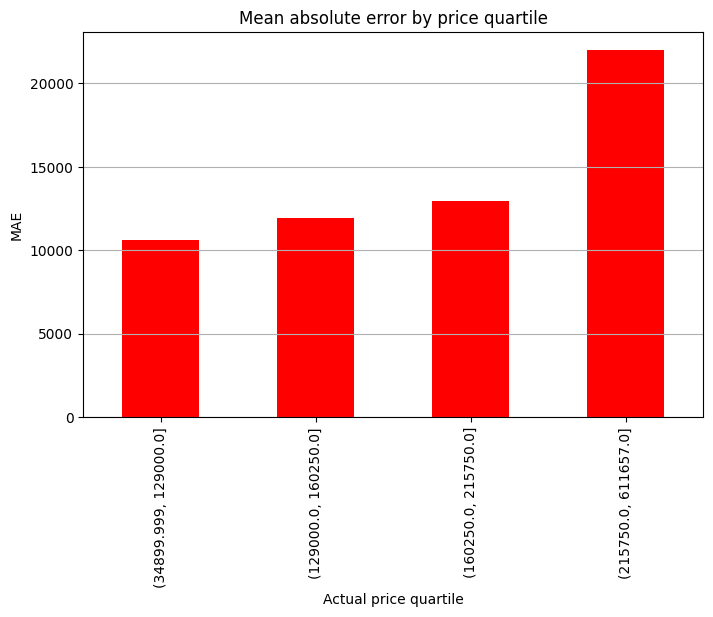

In [27]:
analysis_df = pd.DataFrame(
    {
        "actual": y_test,
        "pred": y_pred,
    }
)

analysis_df["abs_error"] = (analysis_df["actual"] - analysis_df["pred"]).abs()
analysis_df["price_bin"] = pd.qcut(analysis_df["actual"], q=4, duplicates="drop")

segment_error = analysis_df.groupby("price_bin")["abs_error"].agg(
    ["mean", "median", "count"]
)
display(segment_error)

plt.figure(figsize=(8, 5))
segment_error["mean"].plot.bar(color="red")
plt.title("Mean absolute error by price quartile")
plt.ylabel("MAE")
plt.xlabel("Actual price quartile")
plt.grid(True, axis="y")
plt.show()

Learning curve shows the dynamic of learning on train data and validation data.
Model has significant оverfitting, but validation score rises with amount of data, so more data could help.

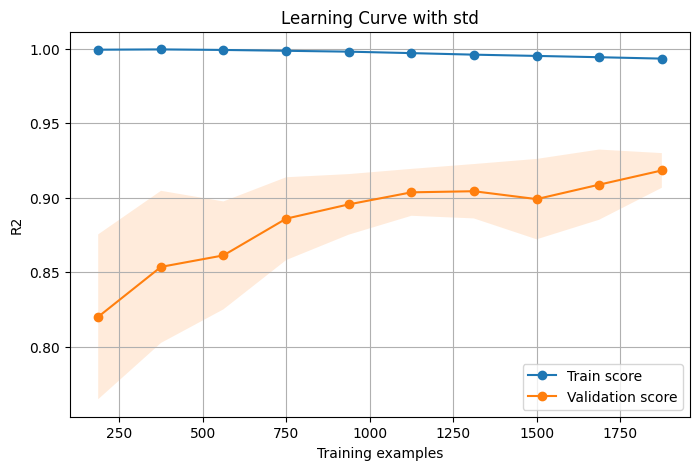

In [28]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_hist_boost_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, marker="o", label="Train score")
plt.plot(train_sizes, val_mean, marker="o", label="Validation score")

plt.fill_between(
    train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15
)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15)

plt.xlabel("Training examples")
plt.ylabel("R2")
plt.title("Learning Curve with std")
plt.legend()
plt.grid(True)
plt.show()